<a name="top" id="top"></a>

<div align="center">
    <h1>Benchmarking</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/murraybj">Benjamin J. L. Murray</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Undergraduate Research Assistant</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_py/5-Benchmarking_python.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Benchmarking (Python)

With the growing availability of unconventional hardware, new algorithms, and increasingly optimized software for optimization problems, a natural question is: which approach is better?
We will call a particular hardware, algorithm, and software combination a solver.
The same question also appears when tuning a single solver: which hyperparameter setting is best for a given problem and resource budget?

In the idealized case where resources are effectively unlimited and the target problem is known in advance, one could exhaustively try every parameter setting for that instance and keep the best one.
In practice, that is rarely possible: the problem is usually not known a priori, and time, memory, and energy are limited.
A more realistic setting is to study a family of similar instances offline, spend additional resources to benchmark that family, and then use those results to guide how we solve a new instance drawn from the same family.


## Example
For illustration purposes, we will use an example that you are already familiar with, which is an Ising model. As a solver, we will use a simulated annealing code provided by D-Wave Ocean Tools.

## Ising model
In order to implement the different Ising Models we will use D-Wave's packages **[dimod](https://github.com/dwavesystems/dimod)** and **[dwave-samplers](https://github.com/dwavesystems/dwave-samplers)**, for defining the Ising model and solving it with simulated annealing, respectively.


### Problem statement

We pose the Ising problem as the following optimization problem:

$$
\min_{s \in \{ \pm 1 \}^n} H(s) = \min_{s \in \{ \pm 1 \}^n} \sum_{(i, j) \in E(G)} J_{i,j}s_is_j + \sum_{i \in V(G)} h_is_i + \beta
$$

where we optimize over spins $s \in \{ \pm 1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{i,j}$ and the linear coefficients are $h_i$.
We also include an arbitrary offset of the Ising model $\beta$.

### Example

Suppose we have an Ising model defined from

$$
h = \begin{bmatrix}
145.0 \\ 122.0 \\ 122.0 \\ 266.0 \\ 266.0 \\ 266.0 \\ 242.5 \\ 266.0 \\ 386.5 \\ 387.0 \\ 386.5
\end{bmatrix},
J = \begin{bmatrix}
0 & 0 & 0 & 24 & 24 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 48 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
\end{bmatrix} \text{ and }
c_I = 1319.5
$$
Let's solve this problem

In [1]:
# If using this on Google collab, we need to install the packages
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

# Let's install dimod and D-Wave's local simulated annealer
if IN_COLAB:
    !pip install -q pyomo
    !pip install dimod
    !pip install dwave-samplers


In [2]:
# Import the Pyomo library, which can be installed via pip, conda or from Github https://github.com/Pyomo/pyomo
import pyomo.environ as pyo
# Import the D-Wave packages dimod and the local simulated annealer
import dimod
from dwave.samplers import SimulatedAnnealingSampler
# Import Matplotlib to generate plots
import matplotlib.pyplot as plt
# Import numpy and scipy for certain numerical calculations below
import numpy as np
import math
import json
from collections import Counter
import pandas as pd
from itertools import chain
import time
import networkx as nx
import os
import pickle
import shutil
import urllib.request
import zipfile
from scipy import stats
from matplotlib import ticker
from matplotlib.colors import Normalize


In [3]:
# These could also be simple lists and numpy matrices
h = {0: 145.0, 1: 122.0, 2: 122.0, 3: 266.0, 4: 266.0, 5: 266.0, 6: 242.5, 7: 266.0, 8: 386.5, 9: 387.0, 10: 386.5}
J = {(0, 3): 24.0, (0, 4): 24.0, (0, 5): 24.0, (0, 7): 24.0, (0, 8): 24.0, (0, 9): 24.0, (0, 10): 24.0, (1, 3): 24.0, (1, 5): 24.0, (1, 6): 24.0, (1, 8): 24.0, (1, 9): 24.0, (1, 10): 24.0, (2, 4): 24.0, (2, 6): 24.0, (2, 7): 24.0, (2, 8): 24.0, (2, 9): 24.0, (2, 10): 24.0, (3, 4): 24.0, (3, 5): 48.0, (3, 6): 24.0, (3, 7): 24.0, (3, 8): 48.0, (3, 9): 48.0, (3, 10): 48.0, (4, 5): 24.0, (4, 6): 24.0, (4, 7): 48.0, (4, 8): 48.0, (4, 9): 48.0, (4, 10): 48.0, (5, 6): 24.0, (5, 7): 24.0, (5, 8): 48.0, (5, 9): 48.0, (5, 10): 48.0, (6, 7): 24.0, (6, 8): 48.0, (6, 9): 48.0, (6, 10): 48.0, (7, 8): 48.0, (7, 9): 48.0, (7, 10): 48.0, (8, 9): 72.0, (8, 10): 72.0, (9, 10): 72.0}
cI = 1319.5


model_ising = dimod.BinaryQuadraticModel.from_ising(h, J, offset=cI) # define the model

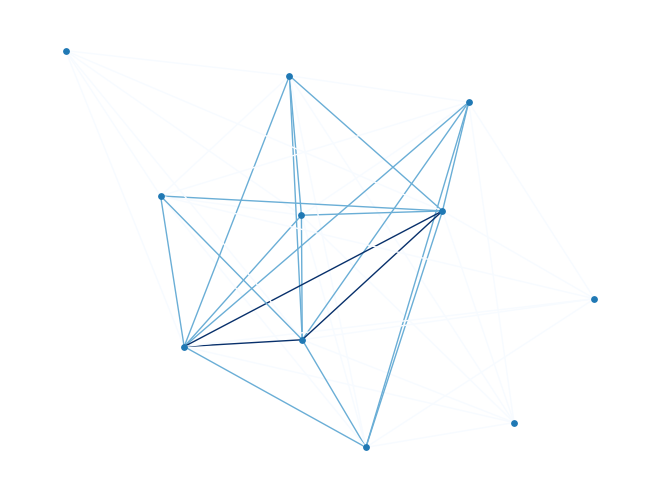

In [4]:
nx_graph = dimod.to_networkx_graph(model_ising)
edges, bias = zip(*nx.get_edge_attributes(nx_graph, 'bias').items())
bias = np.array(bias)
nx.draw(nx_graph, node_size=15, pos=nx.spring_layout(nx_graph),
        edgelist=edges, edge_color=bias, edge_cmap=plt.cm.Blues)
plt.show()


Since the problem is relatively small (11 variables, $2^{11}=2048$ combinations), we can afford to enumerate all the solutions.

In [5]:
exactSampler = dimod.reference.samplers.ExactSolver()
start = time.time()
exactSamples = exactSampler.sample(model_ising)
timeEnum = time.time() - start
print("runtime: " + str(timeEnum) + " seconds")

runtime: 0.0031757354736328125 seconds


In [6]:
# Some useful functions to get plots
def plot_energy_values(results, title=None):

    fig, ax = plt.subplots()

    energies = [datum.energy for datum in results.data(
        ['energy'], sorted_by='energy')]

    if results.vartype == 'Vartype.BINARY':
        samples = [''.join(c for c in str(datum.sample.values()).strip(
            ', ') if c.isdigit()) for datum in results.data(['sample'], sorted_by=None)]
        ax.set(xlabel='bitstring for solution')
    else:
        samples = np.arange(len(energies))
        ax.set(xlabel='solution')

    ax.bar(samples, energies)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Energy')
    if title:
        ax.set_title(str(title))
    print('minimum energy:', min(energies))
    fig.tight_layout()
    return ax


def plot_samples(results, title=None, skip=1):
    fig, ax = plt.subplots()
    energies = results.data_vectors['energy']
    if results.vartype == 'Vartype.BINARY':
        samples = [''.join(c for c in str(datum.sample.values()).strip(
            ', ') if c.isdigit()) for datum in results.data(['sample'], sorted_by=None)]
        ax.set_xlabel('bitstring for solution')
    else:
        samples = np.arange(len(energies))
        ax.set_xlabel('solution')

    counts = Counter(samples)
    total = len(samples)
    for key in counts:
        counts[key] /= total
    df = pd.DataFrame.from_dict(counts, orient='index').sort_index()
    df.plot(kind='bar', legend=None, ax=ax)

    ax.tick_params(axis='x', rotation=80)
    ax.set_xticklabels([t.get_text()[:7] if not i % skip else '' for i, t in enumerate(ax.get_xticklabels())])
    ax.set_ylabel('Probabilities')
    if title:
        ax.set_title(str(title))
    print('minimum energy:', min(energies))
    fig.tight_layout()
    return ax


def plot_energy_cfd(results, title=None, skip=1):
    fig, ax = plt.subplots()
    # skip parameter given to avoid putting all xlabels
    energies = results.data_vectors['energy']
    occurrences = results.data_vectors['num_occurrences']
    total = sum(occurrences)
    counts = {}
    for index, energy in enumerate(energies):
        if energy in counts.keys():
            counts[energy] += occurrences[index]
        else:
            counts[energy] = occurrences[index]
    for key in counts:
        counts[key] /= total
    df = pd.DataFrame.from_dict(counts, orient='index').sort_index()
    df.plot(kind='bar', legend=None, ax=ax)
    ax.set_xticklabels([t.get_text()[:7] if not i % skip else '' for i, t in enumerate(ax.get_xticklabels())])

    ax.set_xlabel('Energy')
    ax.set_ylabel('Probabilities')
    if title:
        ax.set_title(str(title))
    print('minimum energy:', min(energies))
    fig.tight_layout()
    return ax


minimum energy: 5.0


minimum energy: 5.0


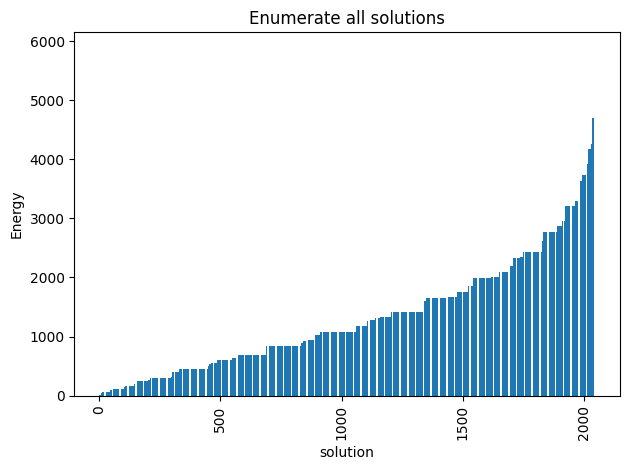

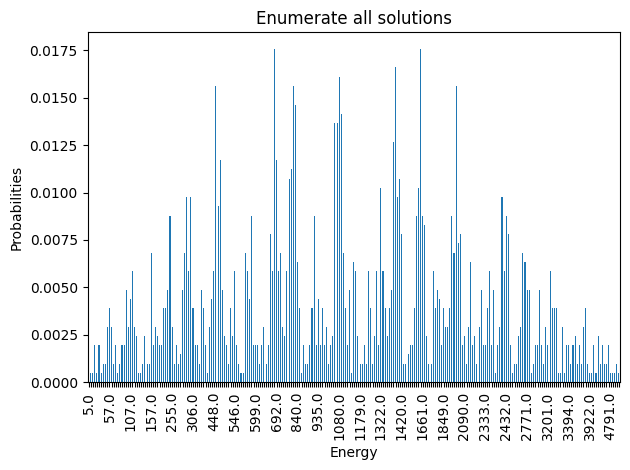

In [7]:
plot_energy_values(exactSamples, title='Enumerate all solutions')
plot_energy_cfd(exactSamples, title='Enumerate all solutions', skip=10)
plt.show()


We observe that the optimal solution of this problem is $x_{10} = 1, 0$ otherwise, leading to an objective of $5$. Notice that this problem has a degenerate optimal solution given that $x_8 = 1, 0$ otherwise also leads to the same solution.

Let's now solve this problem using Simulated Annealing

In [8]:
simAnnSampler = SimulatedAnnealingSampler()
simAnnSamples = simAnnSampler.sample(model_ising, num_reads=1000, seed=42)


minimum energy: 5.0
minimum energy: 5.0


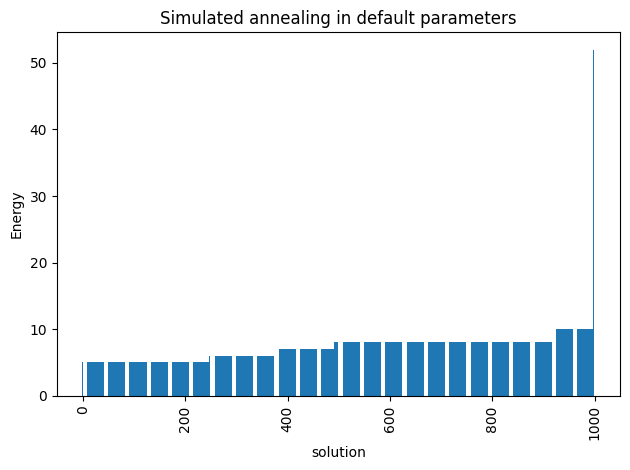

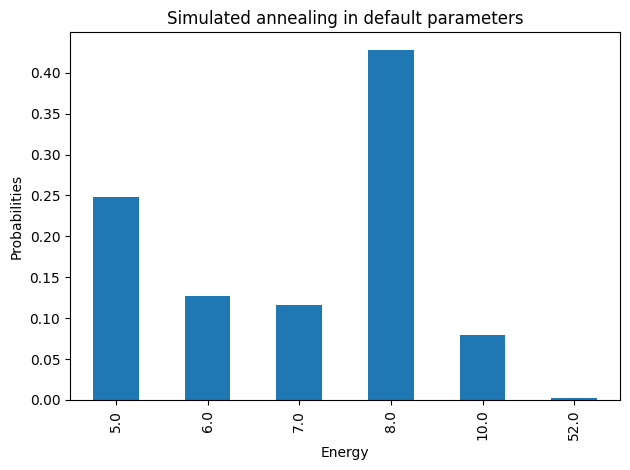

In [9]:
plot_energy_values(simAnnSamples, title='Simulated annealing in default parameters')
plot_energy_cfd(simAnnSamples, title='Simulated annealing in default parameters')
plt.show()


We are going to use the default limits of temperature given by the simulating annealing code. These are defined using the minimum and maximum nonzero coefficients in the Ising model. Then the range for beta is defined as 

$$
\beta \in \left[ \frac{\log(2)}{\max \{ \Delta E \} },\frac{\log(100)}{\min \{ \Delta E \} } \right]
$$

where

$$
\Delta E = \min_{i} \{h_i \} + \sum_j J_{ij}+J_{ji}
$$

Hot temperature: We want to scale hot_beta so that for the most unlikely qubit flip, we get at least 50% chance of flipping. (This means all other qubits will have > 50% chance of flipping initially). Most unlikely flip is when we go from a very low energy state to a high energy state, thus we calculate hot_beta based on max_delta_energy.

$$
0.50 = \exp(-\overline{\beta} * \max \{ \Delta E \})
$$

Cold temperature: Towards the end of the annealing schedule, we want to minimize the chance of flipping. Don't want to be stuck between small energy tweaks. Hence, set cold_beta so that at minimum energy change, the chance of flipping is set to 1%.

$$
0.01 = \exp(-\underline{\beta} * \min \{ \Delta E \})
$$

By default, the schedule also follows a geometric series.

In [10]:
def geomspace(a, b, length=100):
    return np.logspace(np.log10(a), np.log10(b), num=length, endpoint=True)

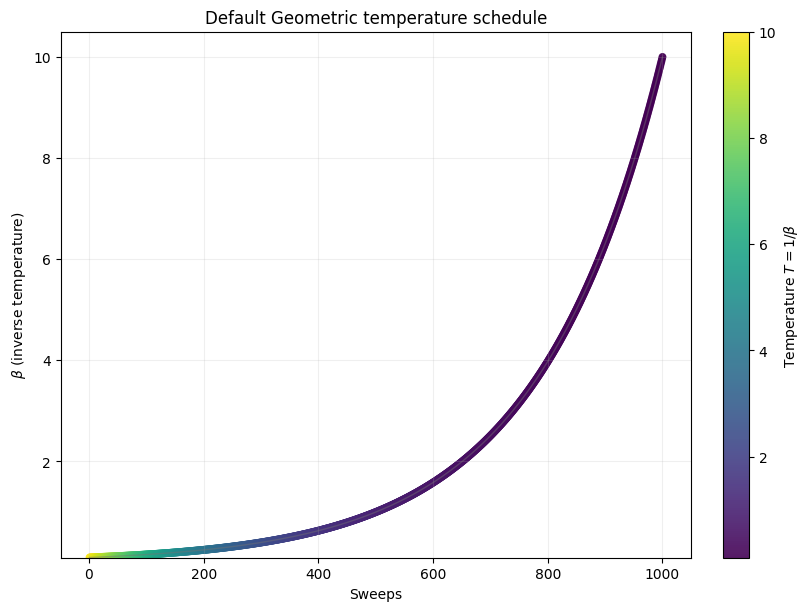

In [11]:
def schedule_values(beta1, beta2, length=1000):
    sweeps = np.arange(1, length + 1)
    beta = np.geomspace(beta1, beta2, num=length)
    temperature = 1.0 / beta
    return sweeps, beta, temperature


def plot_schedule(beta1, beta2, length=1000, title='Default Geometric temperature schedule',
                  ax=None, label=None, cmap='viridis', add_colorbar=True, norm=None,
                  marker='o', line_color='0.45'):
    sweeps, beta, temperature = schedule_values(beta1, beta2, length=length)
    created_ax = ax is None
    if created_ax:
        fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    else:
        fig = ax.figure

    if norm is None:
        norm = Normalize(vmin=float(np.min(temperature)), vmax=float(np.max(temperature)))

    scatter = ax.scatter(
        sweeps,
        beta,
        c=temperature,
        cmap=cmap,
        norm=norm,
        s=22,
        alpha=0.9,
        label=label,
        marker=marker,
    )
    ax.plot(sweeps, beta, color=line_color, linewidth=1, alpha=0.45)
    ax.set_title(title)
    ax.set_xlabel('Sweeps')
    ax.set_ylabel(r'$\beta$ (inverse temperature)')
    ax.set_ylim(float(np.min(beta)) * 0.95, float(np.max(beta)) * 1.05)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.2g}'))
    ax.grid(alpha=0.2)

    if add_colorbar:
        colorbar = fig.colorbar(scatter, ax=ax)
        colorbar.set_label(r'Temperature $T = 1 / \beta$')
    if label is not None:
        ax.legend()

    return fig, ax, scatter


def plot_schedule_pair(beta1, beta2, default_length, best_length):
    lengths = [int(default_length), int(best_length)]
    temperatures = [schedule_values(beta1, beta2, length=length)[2] for length in lengths]
    norm = Normalize(
        vmin=min(float(np.min(values)) for values in temperatures),
        vmax=max(float(np.max(values)) for values in temperatures),
    )

    fig, ax = plt.subplots(figsize=(9.5, 6.0), constrained_layout=True)
    _, _, scatter_reference = plot_schedule(
        beta1,
        beta2,
        length=default_length,
        title='Geometric temperature schedule comparison',
        ax=ax,
        label=f'Default ({default_length} sweeps)',
        add_colorbar=False,
        norm=norm,
        marker='o',
        line_color='0.55',
    )
    plot_schedule(
        beta1,
        beta2,
        length=best_length,
        title='Geometric temperature schedule comparison',
        ax=ax,
        label=f'Best ({best_length} sweeps)',
        add_colorbar=False,
        norm=norm,
        marker='s',
        line_color='0.15',
    )
    colorbar = fig.colorbar(scatter_reference, ax=ax, shrink=0.92)
    colorbar.set_label(r'Temperature $T = 1 / \beta$')
    return fig, ax


beta1 = 0.1
beta2 = 10
_, _, _ = plot_schedule(beta1, beta2)
plt.show()


Now let's compute an expected time metric with respect to the number of sweeps in simulated annealing.

In [12]:
s = 0.99
# sweeps = list(chain(np.arange(1,10,1),np.arange(10,30,2), np.arange(30,50,5), np.arange(50,100,10) ,np.arange(100,1001,100)))
sweeps = list(chain(np.arange(1, 250, 1), np.arange(250, 1001, 10)))
schedules = ['geometric','linear']
opt_energy = 5
results = {}
results['p'] = {}
results['tts'] = {}
results['t']= {}
for schedule in schedules:
    probs = []
    time_to_sol = []
    times = []
    for sweep in sweeps:
        start = time.time()
        samples = simAnnSampler.sample(model_ising, num_reads=1000, num_sweeps=sweep, beta_schedule_type=schedule)
        time_s = time.time() - start
        energies=samples.data_vectors['energy']
        occurrences = samples.data_vectors['num_occurrences']
        total_counts = sum(occurrences)
        counts = {}
        for index, energy in enumerate(energies):
            if energy in counts.keys():
                counts[energy] += occurrences[index]
            else:
                counts[energy] = occurrences[index]
        pr = sum(counts[key]
                 for key in counts.keys() if key <= opt_energy)/total_counts
        probs.append(pr)
        if pr == 0:
            time_to_sol.append(np.inf)
        else:
            time_to_sol.append(time_s*math.log10(1-s)/math.log10(1-pr))
        times.append(time_s)
    results['p'][schedule] = probs
    results['tts'][schedule] = time_to_sol
    results['t'][schedule] = times


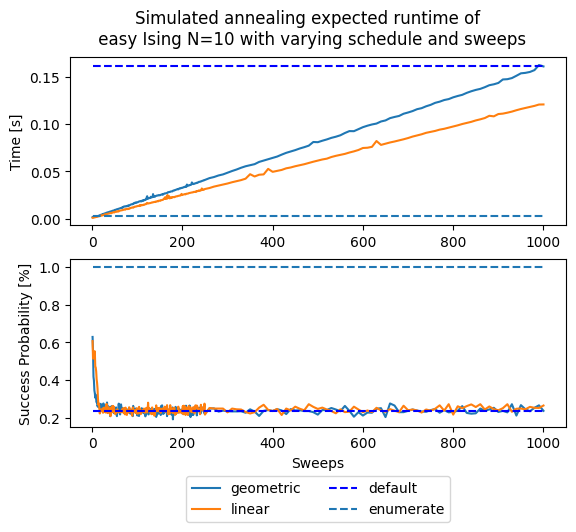

In [13]:
fig, (ax1, ax2) = plt.subplots(2)
fig.suptitle('Simulated annealing expected runtime of \n' +
             ' easy Ising N=10 with varying schedule and sweeps')

for schedule in schedules:
    ax1.plot(sweeps, results['t'][schedule], '-', label=schedule)
ax1.hlines(results['t']['geometric'][-1], sweeps[0], sweeps[-1],
           linestyle='--', label='default', colors='b')
ax1.hlines(timeEnum, sweeps[0], sweeps[-1], linestyle='--', label='enumerate')

ax1.set(ylabel='Time [s]')

for schedule in schedules:
    ax2.plot(sweeps, results['p'][schedule], '-', label=schedule)
ax2.hlines(results['p']['geometric'][-1], sweeps[0], sweeps[-1],
           linestyle='--', label='default', colors='b')
ax2.hlines(1, sweeps[0], sweeps[-1], linestyle='--', label='enumerate')

ax2.set(ylabel='Success Probability [%]')
ax2.set(xlabel='Sweeps')

plt.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.25))

plt.show()


These plots represent two competing objectives: on one hand we want a high probability of success, and on the other hand we want a short runtime.
If a single run succeeds with probability $p$, then the expected number of independent runs needed to reach an overall success probability $s$ is

$$
R = \frac{\log(1-s)}{\log(1-p)}
$$

The quantity reported below is the Time To Solution (TTS), which multiplies this repetition count by the measured runtime of one annealing call:

$$
\mathrm{TTS} = R\, t_{\mathrm{run}} = t_{\mathrm{run}} \frac{\log(1-s)}{\log(1-p)}
$$

We use $s = 99\%$, and $p$ is the observed success probability for the success criterion defined in each experiment.


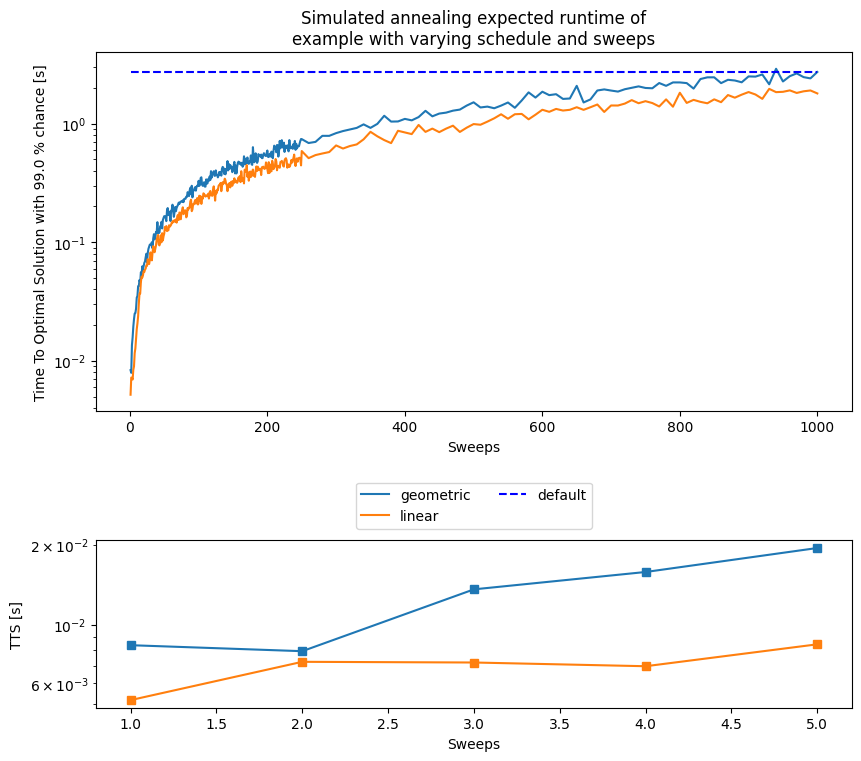

In [14]:
fig, (ax_main, ax_zoom) = plt.subplots(
    2,
    1,
    figsize=(8.5, 7.5),
    height_ratios=[3.0, 1.4],
    constrained_layout=True,
)

for schedule in schedules:
    ax_main.semilogy(sweeps, results['tts'][schedule], '-', label=schedule)

tts_default = results['tts']['geometric'][-1]
ax_main.hlines(tts_default, sweeps[0], sweeps[-1], linestyle='--', label='default', colors='b')
ax_main.set_ylabel('Time To Optimal Solution with ' + str(s * 100) + ' % chance [s]')
ax_main.set_xlabel('Sweeps')
ax_main.set_title('Simulated annealing expected runtime of\nexample with varying schedule and sweeps')
ax_main.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.18))

zoom_slice = slice(0, 5)
for schedule in schedules:
    ax_zoom.semilogy(sweeps[zoom_slice], results['tts'][schedule][zoom_slice], '-s')
ax_zoom.set_ylabel('TTS [s]')
ax_zoom.set_xlabel('Sweeps')
plt.show()


As you can notice, the default parameters given by D-Wave (number of sweeps = 1000 and a geometric update of $\beta$) are not optimal for our tiny example in terms of expected runtime.
This is certainly a function of the problem, for such a small instance having two sweeps are more than enough and more sweeps are an overkill.
This parameters choice might not generalize to any other problem, as seen below.

## Example 2
Let's define a larger model, with 100 variables and random weights, to see how this performance changes.

Assume that we are interested at the instance created with random weights $h_{i}, J_{i, j} \sim U[0, 1]$.

In [15]:
N = 100  # Number of variables
EXAMPLE2_SEED = 42

# Use a small deterministic generator so the Python and Julia
# notebooks benchmark the same random Ising instance.
EXAMPLE2_UINT64_MASK = np.uint64(0xFFFFFFFFFFFFFFFF)
EXAMPLE2_STEP = np.uint64(0xBF58476D1CE4E5B9)


def example2_splitmix64(values):
    z = np.asarray(values, dtype=np.uint64)
    with np.errstate(over='ignore'):
        z = (z + np.uint64(0x9E3779B97F4A7C15)) & EXAMPLE2_UINT64_MASK
        z = ((z ^ (z >> 30)) * np.uint64(0xBF58476D1CE4E5B9)) & EXAMPLE2_UINT64_MASK
        z = ((z ^ (z >> 27)) * np.uint64(0x94D049BB133111EB)) & EXAMPLE2_UINT64_MASK
        z = (z ^ (z >> 31)) & EXAMPLE2_UINT64_MASK
    return z


def example2_uniform_values(count, *seed_parts):
    state = np.uint64(0x123456789ABCDEF0)
    for part in seed_parts:
        state = np.uint64(example2_splitmix64(state ^ np.uint64(int(part) & 0xFFFFFFFFFFFFFFFF)))
    counters = state + np.arange(int(count), dtype=np.uint64) * EXAMPLE2_STEP
    values = example2_splitmix64(counters) >> np.uint64(11)
    return np.asarray(values, dtype=np.float64) * (1.0 / float(1 << 53))


J = np.triu(example2_uniform_values(N * N, EXAMPLE2_SEED, 0, N).reshape(N, N), 1)
h = example2_uniform_values(N, EXAMPLE2_SEED, 1, N)


In [16]:
model_random = dimod.BinaryQuadraticModel.from_ising(h, J, offset=0.0)

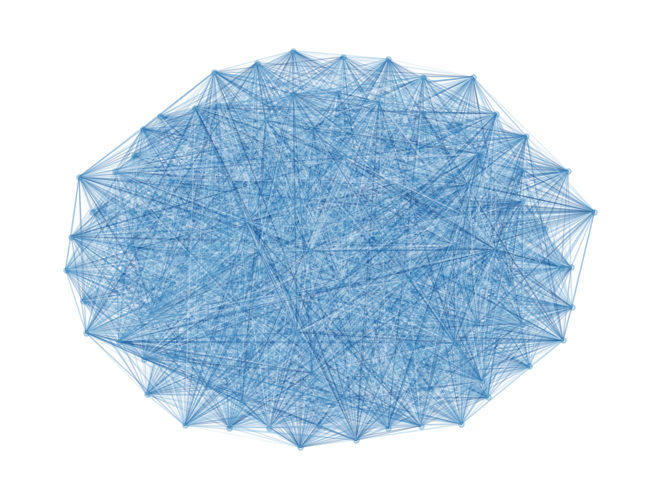

In [17]:
nx_graph = dimod.to_networkx_graph(model_random)
edges, bias = zip(*nx.get_edge_attributes(nx_graph, 'bias').items())
bias = np.array(bias)
nx.draw(nx_graph, node_size=15, pos=nx.spring_layout(nx_graph), alpha=0.25, edgelist=edges, edge_color=bias, edge_cmap=plt.cm.Blues)
plt.show()


For a problem of this size we cannot do a complete enumeration ($2^{100} \approx 1.2e30$) but we can randomly sample the distribution of energies to have a baseline for our later comparisons.

In [18]:
randomSampler = dimod.RandomSampler()
randomSample = randomSampler.sample(model_random, num_reads=1000)
energies = [datum.energy for datum in randomSample.data(
        ['energy'], sorted_by='energy')]
random_energy = np.mean(energies)
print('Average random energy:' + str(random_energy))

Average random energy:-0.1561675209899222


minimum energy: -81.81466527534602


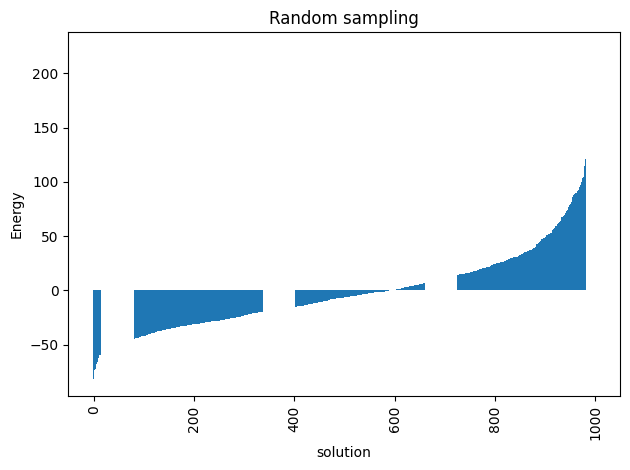

In [19]:
plot_energy_values(randomSample,
               title='Random sampling')
plt.show()


In [20]:
start = time.time()
simAnnSamplesDefault = simAnnSampler.sample(model_random, num_reads=1000, seed=42)
timeDefault = time.time() - start
energies = [datum.energy for datum in simAnnSamplesDefault.data(
        ['energy'], sorted_by='energy')]
min_energy = energies[0]
print("minimum energy: " + str(min_energy))
print("runtime: " + str(timeDefault) + " seconds")


minimum energy: -239.24637050611463
runtime: 2.1055424213409424 seconds


### Problem statement

We pose the Ising problem as the following optimization problem:

$$
\min_{s \in \{ \pm 1 \}^n} H(s) = \min_{s \in \{ \pm 1 \}^n} \sum_{(i, j) \in E(G)} J_{i,j}s_is_j + \sum_{i \in V(G)} h_is_i + \beta
$$

where we optimize over spins $s \in \{ \pm 1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{i,j}$ and the linear coefficients are $h_i$.
We also include an arbitrary offset of the Ising model $\beta$.

minimum energy: -239.24637050611463


minimum energy: -239.24637050611463


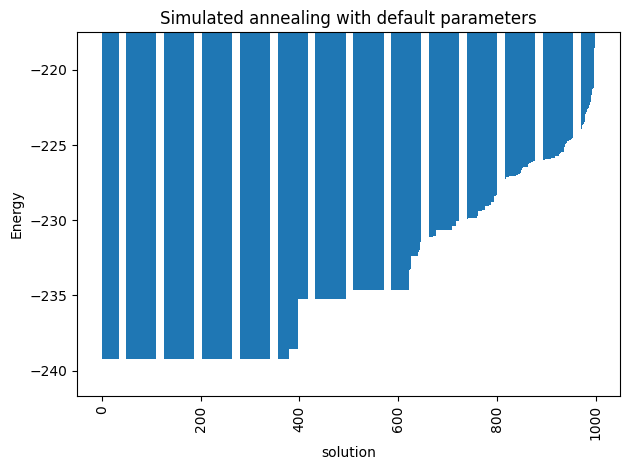

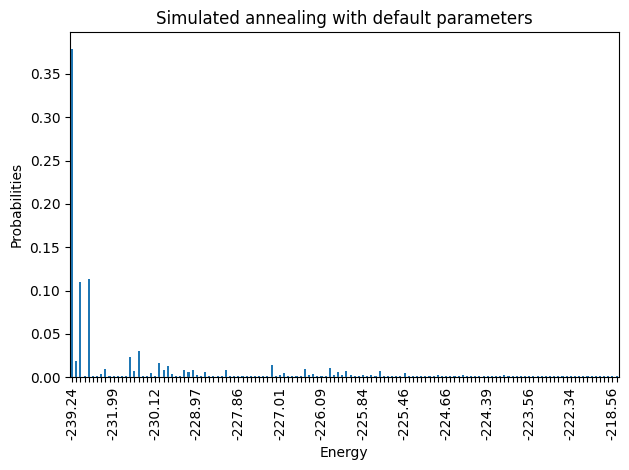

In [21]:
ax_enum = plot_energy_values(simAnnSamplesDefault,
               title='Simulated annealing with default parameters')
ax_enum.set(ylim=[min_energy*(0.99)**np.sign(min_energy), min_energy*(1.1)**np.sign(min_energy)])
plot_energy_cfd(simAnnSamplesDefault,
              title='Simulated annealing with default parameters', skip=10)
plt.show()


Notice that the minimum energy coming from the random sampling and the one from the simulated annealing are very different. 
Moreover, the distributions that both lead to are extremely different too.

{'beta_range': [np.float64(0.006215788820621743), np.float64(31427.48004536868)], 'beta_schedule_type': 'geometric', 'timing': {'preprocessing_ns': 12540259, 'sampling_ns': 2092432943, 'postprocessing_ns': 422830}}


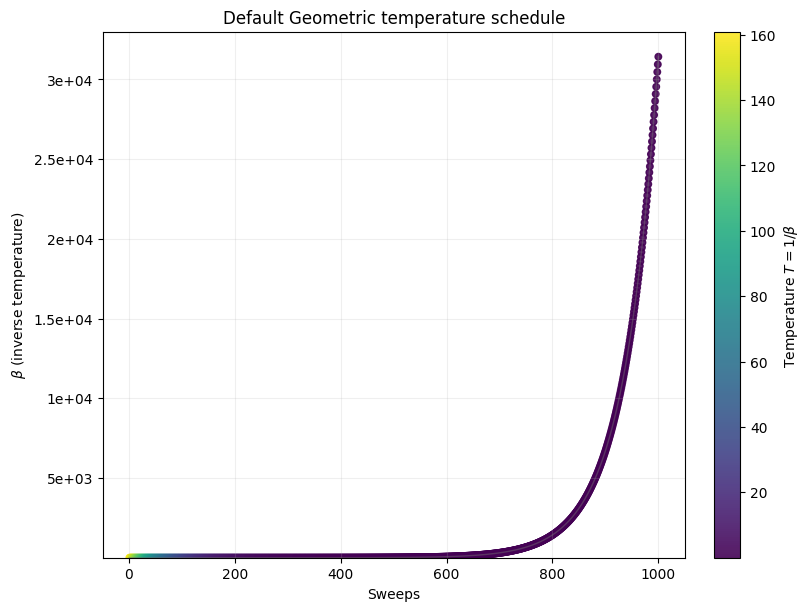

In [22]:
print(simAnnSamplesDefault.info)
default_beta1, default_beta2 = simAnnSamplesDefault.info['beta_range']
schedule_sweeps, beta_schedule, temperature_schedule = schedule_values(default_beta1, default_beta2, length=1000)
_, _, _ = plot_schedule(default_beta1, default_beta2, length=1000, title='Default Geometric temperature schedule')
plt.show()


We can solve this problem with integer programming and certify optimality, but for this notebook we instead define success as reaching a target fraction of the best solution found during the benchmarking campaign.
To compare instances on a common scale, we define the Performance Ratio $\mathrm{PR}$ as

$$
\mathrm{PR} = \frac{E_{\mathrm{rand}} - E_{\mathrm{found}}}{E_{\mathrm{rand}} - E_{\min}}
$$

Here $E_{\mathrm{found}}$ is the best energy observed in the sample, $E_{\mathrm{rand}}$ is the mean energy from the random baseline above, and $E_{\min}$ is the best energy found during the parameter sweep.
This quantity equals $1$ at the best-known energy and can be negative when a method performs worse than the random baseline.
Success is then defined as being within a fixed threshold of this value of $1$.


Before searching for the best parameters, we first try to reuse previously computed results.
If you want to regenerate everything, set `overwrite_pickles = True`; otherwise the notebook will use a local `results.zip` archive when it is available and only recompute missing data.


In [23]:
current_path = os.getcwd()
pickle_path = os.path.join(current_path, 'results')
bundled_zip = os.path.join(current_path, 'results.zip')
if not os.path.exists(pickle_path):
    print('Results directory ' + pickle_path + ' does not exist. We will create it.')
    os.makedirs(pickle_path)


In [24]:
zip_name = os.path.join(pickle_path, 'results.zip')
overwrite_pickles = False
in_colab = 'COLAB_RELEASE_TAG' in os.environ or 'COLAB_JUPYTER_IP' in os.environ or os.path.isdir('/content')
if not os.path.exists(zip_name):
    if os.path.exists(bundled_zip):
        shutil.copyfile(bundled_zip, zip_name)
    elif in_colab:
        urllib.request.urlretrieve('https://github.com/SECQUOIA/QuIP/raw/main/notebooks_py/results.zip', zip_name)
if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(pickle_path)
    print('Results zip file has been extracted to ' + pickle_path)


Results zip file has been extracted to /home/bernalde/repos/QuIP/notebooks_py/results


Now either we have the pickled file or not, let us compute the statistics we are looking for.

In [25]:
s = 0.99  # Success probability used in the TTS calculation
threshold = 5.0  # Percent threshold for the success criterion
sweeps = list(chain(np.arange(1, 250, 1), np.arange(250, 1001, 10)))
# schedules = ['geometric', 'linear']
schedules = ['geometric']
total_reads = 1000
default_sweeps = 1000
n_boot = 1000
ci = 68  # Central bootstrap percentile interval
boots = [1, 10, default_sweeps]
min_energy = -239.5
instance = 42
bootstrap_seed = instance
performance_ratio_label = r'$\mathrm{PR}=\frac{E_{\mathrm{rand}}-E_{\mathrm{found}}}{E_{\mathrm{rand}}-E_{\min}}$'
ANNEAL_CACHE_TAG = 'dwave_samplers_shared_instance_v3'
SCHEDULE_SEED_CODES = {'linear': 1, 'geometric': 2, 'custom': 3}
SEED_TAG_RESULTS_42 = 44
SEED_TAG_INSTANCE_42_PROFILE = 52
SEED_TAG_ALL_RESULTS = 54
SEED_TAG_ENSEMBLE_TTS = 57
SEED_TAG_ENSEMBLE_PR_SWEEPS = 58
SEED_TAG_ENSEMBLE_PR_READS = 59
SEED_TAG_INSTANCE_42_TRANSFER_PROFILE = 62
SEED_TAG_ENSEMBLE_TRANSFER_PROFILE = 65

# NOTEBOOK_5_BENCHMARK_HELPERS_START
use_reference_bootstrap = True
bootstrap_rng_seed = None

# SplitMix64 is only used to make the Python and Julia notebooks draw the
# same bootstrap samples when we want to compare them directly.
# Set `use_reference_bootstrap = False` to use ordinary pseudo-random
# resampling instead.
UINT64_MASK = np.uint64(0xFFFFFFFFFFFFFFFF)
BOOTSTRAP_BOOT_STEP = np.uint64(0x9E3779B97F4A7C15)
BOOTSTRAP_DRAW_STEP = np.uint64(0xBF58476D1CE4E5B9)


def splitmix64(values):
    z = np.asarray(values, dtype=np.uint64)
    with np.errstate(over='ignore'):
        z = (z + np.uint64(0x9E3779B97F4A7C15)) & UINT64_MASK
        z = ((z ^ (z >> 30)) * np.uint64(0xBF58476D1CE4E5B9)) & UINT64_MASK
        z = ((z ^ (z >> 27)) * np.uint64(0x94D049BB133111EB)) & UINT64_MASK
        z = (z ^ (z >> 31)) & UINT64_MASK
    return z


def bootstrap_context_seed(*parts):
    state = np.uint64(0x123456789ABCDEF0)
    for part in parts:
        state = np.uint64(splitmix64(state ^ np.uint64(int(part) & 0xFFFFFFFFFFFFFFFF)))
    return state


def schedule_seed_code(schedule):
    return int(SCHEDULE_SEED_CODES.get(str(schedule), 0))


def anneal_seed(*parts):
    return int(bootstrap_context_seed(*parts) % np.uint64(2147483646)) + 1


def bootstrap_indices(sample_count, draw_count, n_boot, *seed_parts):
    if sample_count <= 0 or draw_count <= 0 or n_boot <= 0:
        raise ValueError('bootstrap dimensions must be positive')

    if use_reference_bootstrap:
        base = bootstrap_context_seed(*seed_parts)
        boot_ids = np.arange(int(n_boot), dtype=np.uint64)[:, None]
        draw_ids = np.arange(int(draw_count), dtype=np.uint64)[None, :]
        counters = base + boot_ids * BOOTSTRAP_BOOT_STEP + draw_ids * BOOTSTRAP_DRAW_STEP
        return np.asarray(splitmix64(counters) % np.uint64(sample_count), dtype=np.intp)

    rng = np.random.default_rng(None if bootstrap_rng_seed is None else int(bootstrap_rng_seed))
    return np.asarray(rng.integers(0, sample_count, size=(int(n_boot), int(draw_count))), dtype=np.intp)


def percentile_interval(values, ci=68):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return (np.nan, np.nan)
    return (
        float(np.percentile(finite, 50.0 - ci / 2.0)),
        float(np.percentile(finite, 50.0 + ci / 2.0)),
    )


def finite_column(values):
    column = np.asarray(values, dtype=float)
    return column[np.isfinite(column)]


def nanmedian_columns(data):
    medians = np.full(data.shape[1], np.nan, dtype=float)
    for index in range(data.shape[1]):
        column = finite_column(data[:, index])
        if column.size:
            medians[index] = np.median(column)
    return medians


def nanstd_columns(data):
    stds = np.full(data.shape[1], np.nan, dtype=float)
    for index in range(data.shape[1]):
        column = finite_column(data[:, index])
        if column.size:
            stds[index] = np.std(column)
    return stds


def nanpercentile_columns(data, q):
    percentiles = np.full(data.shape[1], np.nan, dtype=float)
    for index in range(data.shape[1]):
        column = finite_column(data[:, index])
        if column.size:
            percentiles[index] = np.percentile(column, q)
    return percentiles


def bootstrap(data, n_boot=1000, ci=68, seed_parts=()):
    data = np.asarray(data, dtype=float)
    boot_dist = []
    resampler = bootstrap_indices(data.shape[0], data.shape[0], n_boot, *seed_parts)
    for row in resampler:
        sample = data.take(row, axis=0)
        boot_dist.append(nanmedian_columns(sample))
    b = np.asarray(boot_dist, dtype=float)
    s1 = nanpercentile_columns(b, 50.0 - ci / 2.0)
    s2 = nanpercentile_columns(b, 50.0 + ci / 2.0)
    return (s1, s2)


def performance_ratio(energy, random_energy, min_energy):
    return (float(random_energy) - float(energy)) / (float(random_energy) - float(min_energy))


def performance_ratio_interval(bounds, random_energy, min_energy):
    ratios = [performance_ratio(bound, random_energy, min_energy) for bound in bounds]
    return (float(np.min(ratios)), float(np.max(ratios)))


def bootstrap_minima(energies, sample_size, n_boot, *seed_parts):
    energies = np.asarray(energies, dtype=float)
    resampler = bootstrap_indices(len(energies), sample_size, n_boot, *seed_parts)
    return energies[resampler].min(axis=1)


def time_to_target(runtime_s, success_probability, target_success):
    success_probability = float(np.clip(success_probability, 1e-9, 1.0 - 1e-9))
    return runtime_s * math.log10(1.0 - target_success) / math.log10(1.0 - success_probability)


def summarize_bootstrap_quality(
    energies,
    occurrences,
    boot_sizes,
    *,
    n_boot,
    ci,
    random_energy,
    min_energy,
    success_energy,
    runtime_s,
    target_success,
    seed_parts=(),
):
    energies = np.asarray(energies, dtype=float)
    occurrences = np.asarray(occurrences, dtype=int)
    summary = {}

    for boot in boot_sizes:
        resampler = bootstrap_indices(len(energies), boot, n_boot, *seed_parts, boot)
        boot_samples = energies[resampler]
        boot_occurrences = occurrences[resampler]
        boot_minima = boot_samples.min(axis=1)

        success_rates = []
        for sample_boot, occurrence_boot in zip(boot_samples, boot_occurrences):
            counts = {}
            for energy, count in zip(sample_boot, occurrence_boot):
                counts[energy] = counts.get(energy, 0) + int(count)
            success_rates.append(sum(count for energy, count in counts.items() if energy < success_energy) / boot)

        best_ci = percentile_interval(boot_minima, ci=ci)
        success_rates = np.asarray(success_rates, dtype=float)
        success_rate = float(np.mean(success_rates))
        if not np.all(success_rates > 0):
            tts_value = np.inf
            tts_ci = (np.inf, np.inf)
        else:
            success_ci = percentile_interval(success_rates, ci=ci)
            tts_value = time_to_target(runtime_s, success_rate, target_success)
            tts_ci = tuple(sorted((
                time_to_target(runtime_s, success_ci[0], target_success),
                time_to_target(runtime_s, success_ci[1], target_success),
            )))

        summary[boot] = {
            'probability': success_rate,
            'tts': tts_value,
            'tts_ci': tts_ci,
            'best_energy': float(np.mean(boot_minima)),
            'best_energy_ci': best_ci,
            'performance_ratio': performance_ratio(float(np.mean(boot_minima)), random_energy, min_energy),
            'performance_ratio_ci': performance_ratio_interval(best_ci, random_energy, min_energy),
        }

    return summary


def build_performance_ratio_profile(energies, draw_counts, *, n_boot, random_energy, min_energy, ci=68, seed_parts=()):
    ratios = []
    ratio_intervals = []
    for draw_count in draw_counts:
        draw_count = int(draw_count)
        boot_dist = bootstrap_minima(energies, draw_count, n_boot, *seed_parts, draw_count)
        ratios.append(performance_ratio(float(np.mean(boot_dist)), random_energy, min_energy))
        ratio_intervals.append(performance_ratio_interval(percentile_interval(boot_dist, ci=ci), random_energy, min_energy))
    return np.asarray(ratios, dtype=float), np.asarray(ratio_intervals, dtype=float)


def deterministic_uniform_values(count, *seed_parts):
    count = int(count)
    base = bootstrap_context_seed(*seed_parts)
    counters = base + np.arange(count, dtype=np.uint64) * BOOTSTRAP_DRAW_STEP
    values = splitmix64(counters) >> np.uint64(11)
    return np.asarray(values, dtype=np.float64) * (1.0 / float(1 << 53))


def build_random_ising_instance(instance_seed, size):
    J_values = deterministic_uniform_values(size * size, instance_seed, 0, size).reshape(size, size)
    J = np.triu(J_values, 1)
    h = deterministic_uniform_values(size, instance_seed, 1, size)
    model = dimod.BinaryQuadraticModel.from_ising(h, J, offset=0.0)
    return J, h, model


def load_or_generate_sa_samples(instance_seed, schedule, sweep, model, sampler, pickle_path, *, overwrite_pickles=False, total_reads=1000):
    pickle_name = os.path.join(pickle_path, f'{instance_seed}_{schedule}_{sweep}_{ANNEAL_CACHE_TAG}.p')
    if os.path.exists(pickle_name) and not overwrite_pickles:
        with open(pickle_name, 'rb') as fh:
            samples = pickle.load(fh)
        time_s = float(samples.info['timing'])
    else:
        start = time.time()
        seed = anneal_seed(instance_seed, schedule_seed_code(schedule), sweep, total_reads)
        samples = sampler.sample(
            model,
            num_reads=total_reads,
            num_sweeps=sweep,
            beta_schedule_type=schedule,
            seed=seed,
        )
        time_s = time.time() - start
        samples.info['timing'] = time_s
        samples.info['seed'] = seed
        samples.info['cache_tag'] = ANNEAL_CACHE_TAG
        with open(pickle_name, 'wb') as fh:
            pickle.dump(samples, fh)
    return samples, time_s


def zoom_window_from_series(*series, pad=5):
    candidate_indices = []
    max_length = 0
    for values in series:
        array = np.asarray(values, dtype=float)
        array[~np.isfinite(array)] = np.nan
        max_length = max(max_length, len(array))
        if np.any(np.isfinite(array)):
            candidate_indices.append(int(np.nanargmin(array)))
    if not candidate_indices:
        return slice(0, max_length)
    range_lo = max(0, min(candidate_indices) - pad)
    range_hi = min(max_length, max(candidate_indices) + pad + 1)
    return slice(range_lo, range_hi)
# NOTEBOOK_5_BENCHMARK_HELPERS_END


results_name = os.path.join(pickle_path, f'results_{instance}.pkl')
results = {
    'p': {},
    'min_energy': {},
    'random_energy': {},
    'tts': {},
    'ttsci': {},
    't': {},
    'best': {},
    'bestci': {},
}

if not os.path.exists(results_name):
    for boot in boots:
        results['p'][boot] = {}
        results['tts'][boot] = {}
        results['ttsci'][boot] = {}
        results['best'][boot] = {}
        results['bestci'][boot] = {}

    for schedule in schedules:
        probs = {k: [] for k in boots}
        time_to_sol = {k: [] for k in boots}
        ttscs = {k: [] for k in boots}
        times = []
        best_values = {k: [] for k in boots}
        best_intervals = {k: [] for k in boots}

        for sweep in sweeps:
            samples, time_s = load_or_generate_sa_samples(
                instance,
                schedule,
                sweep,
                model_random,
                simAnnSampler,
                pickle_path,
                overwrite_pickles=overwrite_pickles,
                total_reads=total_reads,
            )

            energies = np.asarray(samples.data_vectors['energy'], dtype=float)
            occurrences = np.asarray(samples.data_vectors['num_occurrences'], dtype=int)
            times.append(time_s)

            current_min_energy = float(np.min(energies))
            if current_min_energy < min_energy:
                min_energy = current_min_energy
                print('A better solution of ' + str(min_energy) + ' was found for sweep ' + str(sweep))

            success = random_energy - (random_energy - min_energy) * (1.0 - threshold / 100.0)
            summary = summarize_bootstrap_quality(
                energies,
                occurrences,
                boots,
                n_boot=n_boot,
                ci=ci,
                random_energy=random_energy,
                min_energy=min_energy,
                success_energy=success,
                runtime_s=time_s,
                target_success=s,
                seed_parts=(bootstrap_seed, SEED_TAG_RESULTS_42, sweep),
            )

            for boot in boots:
                probs[boot].append(summary[boot]['probability'])
                time_to_sol[boot].append(summary[boot]['tts'])
                ttscs[boot].append(summary[boot]['tts_ci'])
                best_values[boot].append(summary[boot]['performance_ratio'])
                best_intervals[boot].append(summary[boot]['performance_ratio_ci'])

        results['t'][schedule] = times
        results['min_energy'][schedule] = min_energy
        results['random_energy'][schedule] = random_energy
        for boot in boots:
            results['p'][boot][schedule] = probs[boot]
            results['tts'][boot][schedule] = time_to_sol[boot]
            results['ttsci'][boot][schedule] = ttscs[boot]
            results['best'][boot][schedule] = best_values[boot]
            results['bestci'][boot][schedule] = best_intervals[boot]

    with open(results_name, 'wb') as fh:
        pickle.dump(results, fh)
else:
    with open(results_name, 'rb') as fh:
        results = pickle.load(fh)


After gathering all the results, we would like to see how the Performance Ratio evolves as we increase the number of sweeps.
To account for the stochasticity of this method, we bootstrap the best energy reached at each sample size and report central bootstrap percentile intervals.
The helper functions above default to a deterministic SplitMix64 resampler so the Python and Julia notebooks use identical bootstrap draws when we compare them directly.
Set `use_reference_bootstrap = False` if you prefer standard pseudo-random resampling instead.


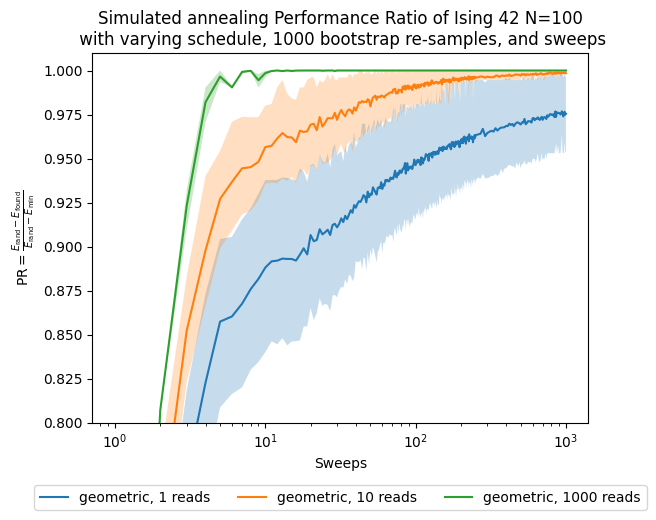

In [26]:
fig, ax = plt.subplots()
for boot in boots:
    for schedule in schedules:
        ax.plot(sweeps, results['best'][boot][schedule], label=str(schedule) + ', ' + str(boot) + ' reads')
        bestnp = np.stack(results['bestci'][boot][schedule], axis=0).T
        ax.fill_between(sweeps, bestnp[0], bestnp[1], alpha=0.25)
ax.set(xlabel='Sweeps')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of Ising 42 N=100\n' +
          ' with varying schedule, ' + str(n_boot) + ' bootstrap re-samples, and sweeps')
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.set(xscale='log')
ax.set(ylim=[0.8, 1.01])
plt.show()


Now, besides looking at the sweeps, which are our parameter, we want to see how the performance changes with respect to the number of shots, which in this case are proportional to the computational time/effort that it takes to solve the problem.

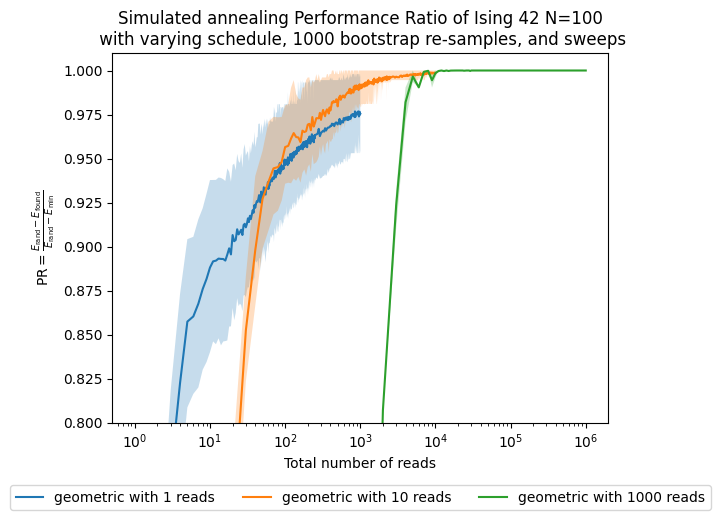

In [27]:
fig, ax = plt.subplots()
for boot in boots:
    reads = [s * boot for s in sweeps]
    for schedule in schedules:
        ax.plot(reads, results['best'][boot][schedule], label=str(schedule) + ' with ' + str(boot) + ' reads')
        bestnp = np.stack(results['bestci'][boot][schedule], axis=0).T
        ax.fill_between(reads, bestnp[0], bestnp[1], alpha=0.25)
ax.set(xlabel='Total number of reads')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of Ising 42 N=100\n' +
          ' with varying schedule, ' + str(n_boot) + ' bootstrap re-samples, and sweeps')
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.set(xscale='log')
ax.set(ylim=[0.8, 1.01])
plt.show()


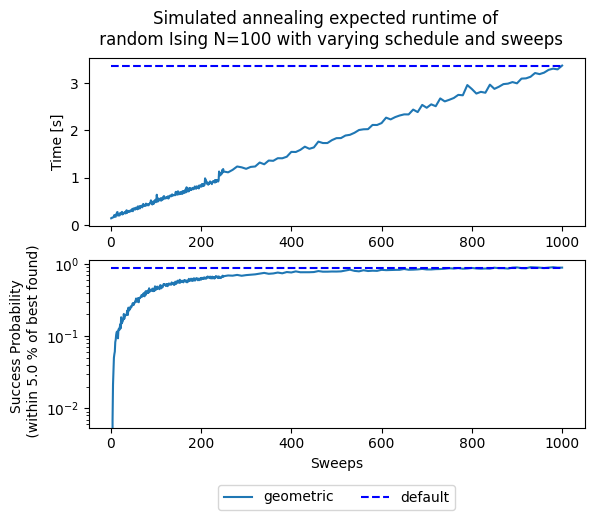

In [28]:
fig, (ax1, ax2) = plt.subplots(2)
fig.suptitle('Simulated annealing expected runtime of \n' +
             ' random Ising N=100 with varying schedule and sweeps')

for schedule in schedules:
    ax1.plot(sweeps, results['t'][schedule], '-', label=schedule)
ax1.hlines(results['t']['geometric'][-1], sweeps[0], sweeps[-1],
           linestyle='--', label='default', colors='b')

ax1.set(ylabel='Time [s]')

for schedule in schedules:
    ax2.semilogy(sweeps, results['p'][default_sweeps][schedule], '-', label=schedule)
ax2.hlines(results['p'][default_sweeps]['geometric'][-1], sweeps[0], sweeps[-1],
           linestyle='--', label='default', colors='b')

ax2.set(ylabel='Success Probability \n (within ' + str(threshold) + ' % of best found)')
ax2.set(xlabel='Sweeps')
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.3))
plt.show()


minimum TTS for geometric schedule = 3.3120138340301897s at sweep = 85


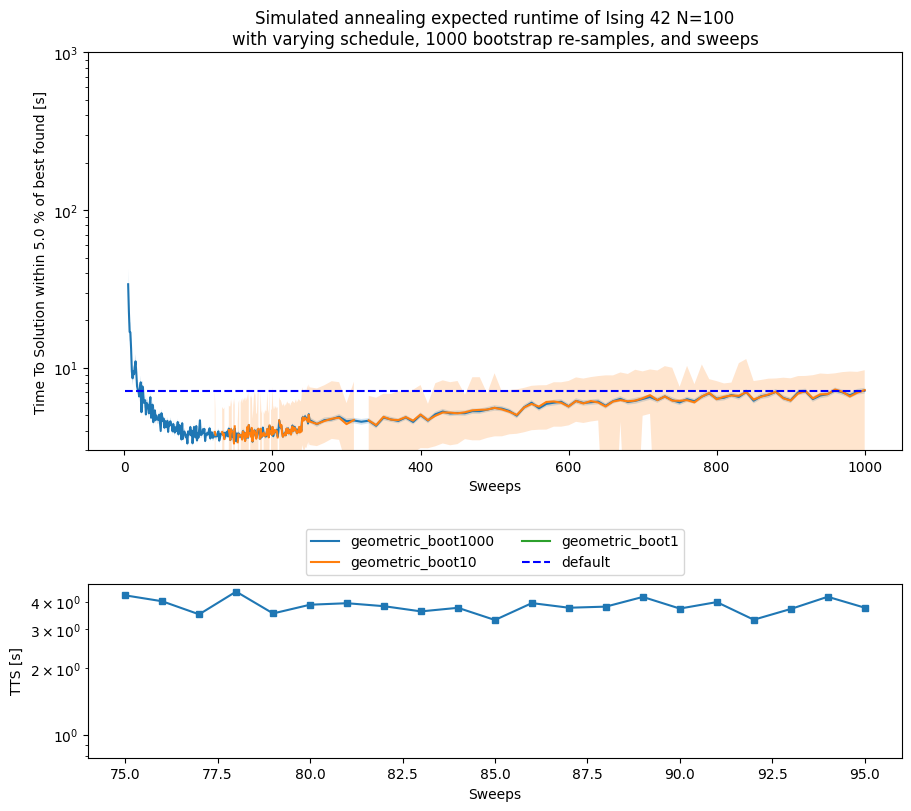

In [29]:
fig, (ax_main, ax_zoom) = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    height_ratios=[3.2, 1.4],
    constrained_layout=True,
)

for boot in reversed(boots):
    for schedule in schedules:
        ax_main.plot(sweeps, results['tts'][boot][schedule], label=schedule + '_boot' + str(boot))
        ttsnp = np.asarray(results['ttsci'][boot][schedule], dtype=float)
        ax_main.fill_between(sweeps, ttsnp[:, 0], ttsnp[:, 1], alpha=0.2)

default_tts = results['tts'][total_reads]['geometric'][-1]
ax_main.hlines(default_tts, sweeps[0], sweeps[-1], linestyle='--', label='default', colors='b')
ax_main.set(yscale='log')
ax_main.set(ylim=[3, 1e3])
ax_main.set(ylabel='Time To Solution within ' + str(threshold) + ' % of best found [s]')
ax_main.set(xlabel='Sweeps')
ax_main.set_title('Simulated annealing expected runtime of Ising 42 N=100\n' +
                  'with varying schedule, ' + str(n_boot) + ' bootstrap re-samples, and sweeps')
ax_main.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)

zoom_reference = []
for schedule in schedules:
    instance_tts = np.asarray(results['tts'][default_sweeps][schedule], dtype=float)
    instance_tts[~np.isfinite(instance_tts)] = np.nan
    min_index = int(np.nanargmin(instance_tts))
    min_tts = float(instance_tts[min_index])
    min_sweep = sweeps[min_index]
    print('minimum TTS for ' + schedule + ' schedule = ' + str(min_tts) + 's at sweep = ' + str(min_sweep))
    zoom_reference.append(instance_tts)

zoom_slice = zoom_window_from_series(*zoom_reference, pad=10)
for boot in reversed(boots):
    for schedule in schedules:
        boot_tts = np.asarray(results['tts'][boot][schedule], dtype=float)
        boot_tts[~np.isfinite(boot_tts)] = np.nan
        ax_zoom.semilogy(sweeps[zoom_slice], boot_tts[zoom_slice], '-s', markersize=4)

ax_zoom.hlines(default_tts, sweeps[zoom_slice.start], sweeps[zoom_slice.stop - 1],
               linestyle='--', label='default', colors='b')
ax_zoom.set(ylabel='TTS [s]')
ax_zoom.set(xlabel='Sweeps')
plt.show()


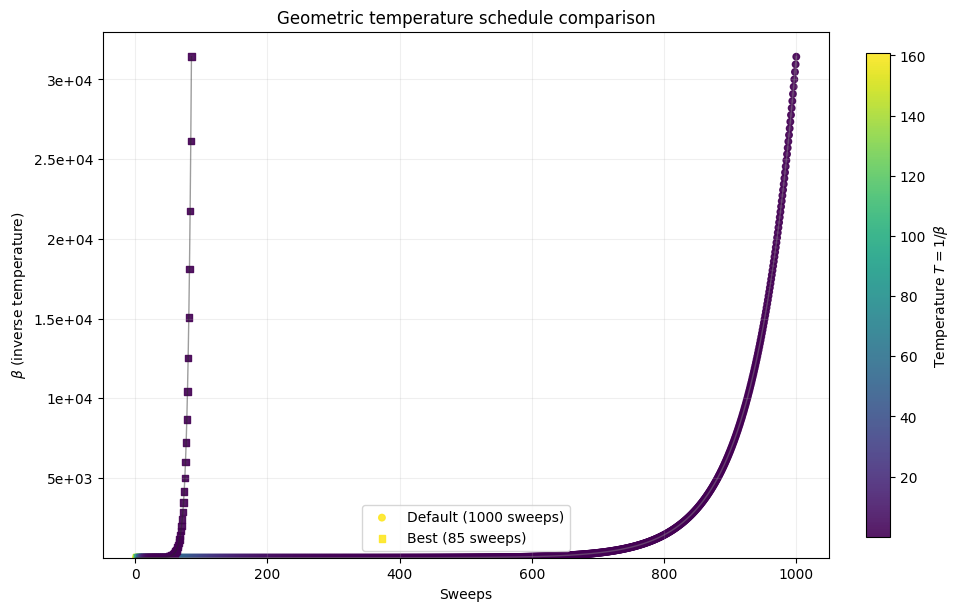

In [30]:
default_beta1, default_beta2 = simAnnSamplesDefault.info['beta_range']
_, _ = plot_schedule_pair(default_beta1, default_beta2, default_sweeps, min_sweep)
plt.show()


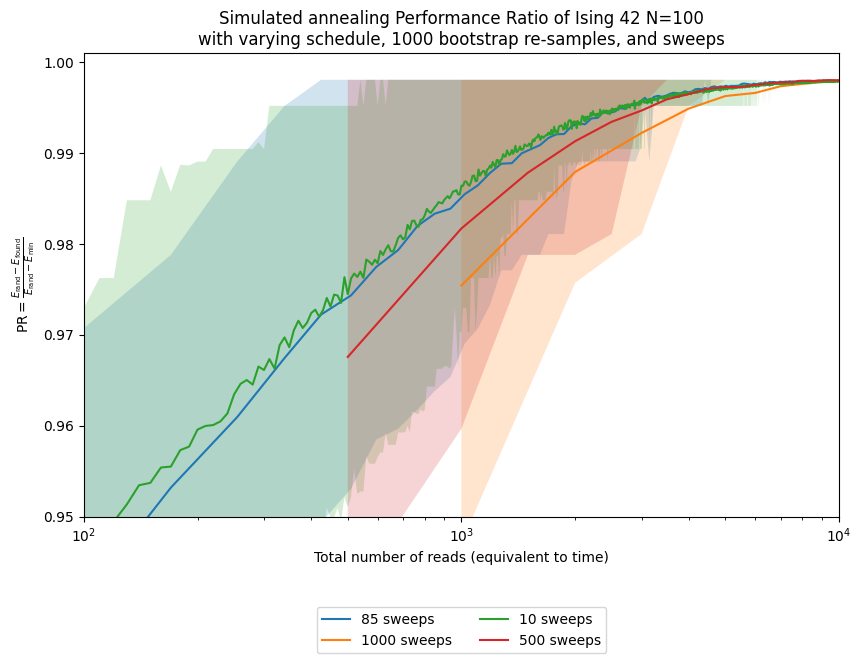

In [31]:
fig, ax = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
shots = list(range(1, total_reads))
interest_sweeps = list(dict.fromkeys([min_sweep, default_sweeps, 10, 500]))
approx_ratio = {schedule: {} for schedule in schedules}
approx_ratioci = {schedule: {} for schedule in schedules}

instance = 42
for schedule in schedules:
    schedule_min_energy = results['min_energy'][schedule]
    schedule_random_energy = results['random_energy'][schedule]

    for sweep in interest_sweeps:
        samples, _ = load_or_generate_sa_samples(
            instance,
            schedule,
            sweep,
            model_random,
            simAnnSampler,
            pickle_path,
            overwrite_pickles=overwrite_pickles,
            total_reads=total_reads,
        )

        energies = np.asarray(samples.data_vectors['energy'], dtype=float)
        schedule_min_energy = min(schedule_min_energy, float(np.min(energies)))
        ratios, ratio_ci = build_performance_ratio_profile(
            energies,
            shots,
            n_boot=n_boot,
            random_energy=schedule_random_energy,
            min_energy=schedule_min_energy,
            ci=ci,
            seed_parts=(bootstrap_seed, SEED_TAG_INSTANCE_42_PROFILE, sweep),
        )

        approx_ratio[schedule][sweep] = ratios
        approx_ratioci[schedule][sweep] = ratio_ci

        reads = np.asarray([shot * sweep for shot in shots], dtype=float)
        ax.plot(reads, ratios, label=str(sweep) + ' sweeps')
        ax.fill_between(reads, ratio_ci[:, 0], ratio_ci[:, 1], alpha=0.2)

ax.set(xscale='log')
ax.set(ylim=[0.95, 1.001])
ax.set(xlim=[1e2, 1e4])
ax.set(xlabel='Total number of reads (equivalent to time)')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of Ising 42 N=100\n' +
          'with varying schedule, ' + str(n_boot) + ' bootstrap re-samples, and sweeps')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)
plt.show()


Here we see how using the optimal number of sweeps improves performance relative to other values, including the solver default.
Of course, we only know that after running the full experiment on this specific instance.
In practice, we instead ask how well parameters chosen from similar, but not identical, instances transfer.
To study that, we generate 20 random instances with the same size and distribution but different random seeds.


In [32]:
s = 0.99  # Success probability used in the TTS calculation
threshold = 5.0  # Percent threshold for the success criterion
sweeps = list(chain(np.arange(1, 250, 1), np.arange(250, 1001, 10)))
schedules = ['geometric']
total_reads = 1000
default_sweeps = 1000
boots = [1, 10, default_sweeps]
all_results = {}
instances = range(20)

all_results_name = os.path.join(pickle_path, 'all_results.pkl')
if not os.path.exists(all_results_name):
    for instance in instances:
        all_results[instance] = {
            'p': {},
            'min_energy': {},
            'random_energy': {},
            'tts': {},
            'ttsci': {},
            't': {},
            'best': {},
            'bestci': {},
        }

        _, _, instance_model = build_random_ising_instance(instance, N)
        random_sample = randomSampler.sample(instance_model, num_reads=total_reads)
        random_energies = [datum.energy for datum in random_sample.data(['energy'])]
        random_energy = float(np.mean(random_energies))

        default_samples, _ = load_or_generate_sa_samples(
            instance,
            'geometric',
            default_sweeps,
            instance_model,
            simAnnSampler,
            pickle_path,
            overwrite_pickles=overwrite_pickles,
            total_reads=total_reads,
        )
        instance_min_energy = float(np.min(np.asarray(default_samples.data_vectors['energy'], dtype=float)))

        for schedule in schedules:
            probs = {k: [] for k in boots}
            time_to_sol = {k: [] for k in boots}
            ttscs = {k: [] for k in boots}
            times = []
            best_values = {k: [] for k in boots}
            best_intervals = {k: [] for k in boots}
            current_min_energy = instance_min_energy

            for sweep in sweeps:
                samples, time_s = load_or_generate_sa_samples(
                    instance,
                    schedule,
                    sweep,
                    instance_model,
                    simAnnSampler,
                    pickle_path,
                    overwrite_pickles=overwrite_pickles,
                    total_reads=total_reads,
                )

                energies = np.asarray(samples.data_vectors['energy'], dtype=float)
                occurrences = np.asarray(samples.data_vectors['num_occurrences'], dtype=int)
                times.append(time_s)

                current_min_energy = min(current_min_energy, float(np.min(energies)))
                success = random_energy - (random_energy - current_min_energy) * (1.0 - threshold / 100.0)
                summary = summarize_bootstrap_quality(
                    energies,
                    occurrences,
                    boots,
                    n_boot=n_boot,
                    ci=ci,
                    random_energy=random_energy,
                    min_energy=current_min_energy,
                    success_energy=success,
                    runtime_s=time_s,
                    target_success=s,
                    seed_parts=(bootstrap_seed, SEED_TAG_ALL_RESULTS, instance, sweep),
                )

                for boot in boots:
                    probs[boot].append(summary[boot]['probability'])
                    time_to_sol[boot].append(summary[boot]['tts'])
                    ttscs[boot].append(summary[boot]['tts_ci'])
                    best_values[boot].append(summary[boot]['performance_ratio'])
                    best_intervals[boot].append(summary[boot]['performance_ratio_ci'])

            all_results[instance]['t'][schedule] = {default_sweeps: times}
            all_results[instance]['min_energy'][schedule] = {default_sweeps: current_min_energy}
            all_results[instance]['random_energy'][schedule] = {default_sweeps: random_energy}
            all_results[instance]['p'][schedule] = {boot: probs[boot] for boot in boots}
            all_results[instance]['tts'][schedule] = {boot: time_to_sol[boot] for boot in boots}
            all_results[instance]['ttsci'][schedule] = {boot: ttscs[boot] for boot in boots}
            all_results[instance]['best'][schedule] = {boot: best_values[boot] for boot in boots}
            all_results[instance]['bestci'][schedule] = {boot: best_intervals[boot] for boot in boots}

    with open(all_results_name, 'wb') as fh:
        pickle.dump(all_results, fh)
else:
    with open(all_results_name, 'rb') as fh:
        all_results = pickle.load(fh)


In [33]:
def tsplotboot(ax, x, data, error_est, seed_parts=(), **kw):
    data = np.asarray(data, dtype=float)
    if x is None:
        x = np.arange(data.shape[1])
    x = np.asarray(x, dtype=float)
    est = nanmedian_columns(data)
    if error_est == 'bootstrap':
        cis = bootstrap(data, seed_parts=seed_parts)
    elif error_est == 'std':
        sd = nanstd_columns(data)
        cis = (est - sd, est + sd)
    else:
        raise ValueError(f'unsupported error estimate: {error_est}')

    ci_low = np.asarray(cis[0], dtype=float)
    ci_high = np.asarray(cis[1], dtype=float)
    mask = np.isfinite(x) & np.isfinite(est) & np.isfinite(ci_low) & np.isfinite(ci_high)
    if not np.any(mask):
        return ax

    fill_kw = dict(kw)
    fill_kw.pop('label', None)
    fill_kw.setdefault('alpha', 0.25)
    ax.fill_between(x[mask], ci_low[mask], ci_high[mask], **fill_kw)
    ax.plot(x[mask], est[mask], **kw)
    ax.margins(x=0)
    return ax


Now we bootstrap the results across the full ensemble of instances and summarize them with the median, which is more robust than the mean for these skewed runtime distributions.


minimum median TTS for geometric schedule = 2.130041451027739s at sweep = 112
minimum TTS for instance 42 with geometric schedule = 3.3120138340301897s at sweep = 85


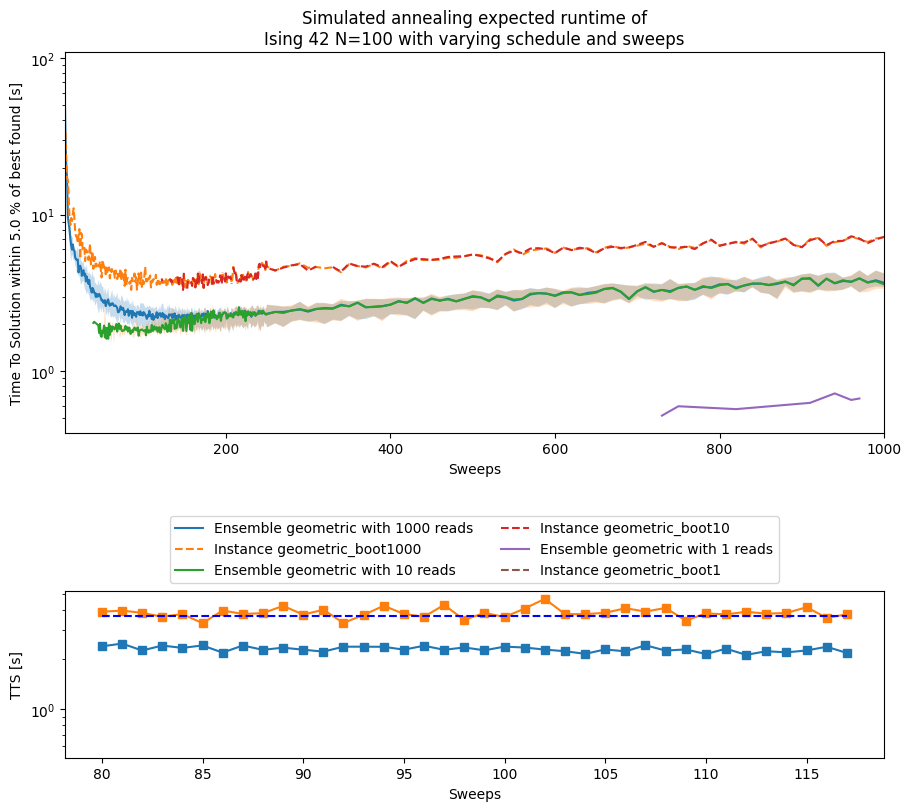

In [34]:
fig, (ax_main, ax_zoom) = plt.subplots(
    2,
    1,
    figsize=(9, 8),
    height_ratios=[3.2, 1.4],
    constrained_layout=True,
)

median_tts = None
instance_tts = None
min_median_sweep = default_sweeps
for boot in reversed(boots):
    for schedule in schedules:
        results_array = np.asarray([
            np.asarray(all_results[i]['tts'][schedule][boot], dtype=float)
            for i in range(20)
        ], dtype=float)
        results_array[~np.isfinite(results_array)] = np.nan
        tsplotboot(
            ax_main,
            x=np.asarray(sweeps),
            data=results_array,
            error_est='bootstrap',
            seed_parts=(bootstrap_seed, SEED_TAG_ENSEMBLE_TTS, boot),
            label='Ensemble ' + schedule + ' with ' + str(boot) + ' reads',
        )
        ax_main.plot(
            sweeps,
            results['tts'][boot][schedule],
            label='Instance ' + schedule + '_boot' + str(boot),
            linestyle='--',
        )

        if boot == default_sweeps:
            median_tts = nanmedian_columns(results_array)
            instance_tts = np.asarray(results['tts'][boot][schedule], dtype=float)
            instance_tts[~np.isfinite(instance_tts)] = np.nan
            min_median_index = int(np.nanargmin(median_tts))
            min_median_tts = float(median_tts[min_median_index])
            min_median_sweep = sweeps[min_median_index]
            min_index = int(np.nanargmin(instance_tts))
            min_tts = float(instance_tts[min_index])
            min_sweep = sweeps[min_index]
            print('minimum median TTS for ' + schedule + ' schedule = ' + str(min_median_tts) + 's at sweep = ' + str(min_median_sweep))
            print('minimum TTS for instance 42 with ' + schedule + ' schedule = ' + str(min_tts) + 's at sweep = ' + str(min_sweep))

ax_main.set(yscale='log')
ax_main.set(ylabel='Time To Solution within ' + str(threshold) + ' % of best found [s]')
ax_main.set(xlabel='Sweeps')
ax_main.set_title('Simulated annealing expected runtime of\nIsing 42 N=100 with varying schedule and sweeps')
ax_main.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

zoom_slice = zoom_window_from_series(median_tts, instance_tts, pad=5)
ax_zoom.semilogy(sweeps[zoom_slice], median_tts[zoom_slice], '-s', label='ensemble median')
ax_zoom.semilogy(sweeps[zoom_slice], instance_tts[zoom_slice], '-s', label='instance 42')
default_values = np.asarray([
    all_results[i]['tts']['geometric'][default_sweeps][-1]
    for i in range(20)
], dtype=float)
default_values[~np.isfinite(default_values)] = np.nan
ax_zoom.hlines(
    float(np.nanmedian(default_values)),
    sweeps[zoom_slice.start],
    sweeps[zoom_slice.stop - 1],
    linestyle='--',
    colors='b',
)
ax_zoom.set(ylabel='TTS [s]')
ax_zoom.set(xlabel='Sweeps')
plt.show()


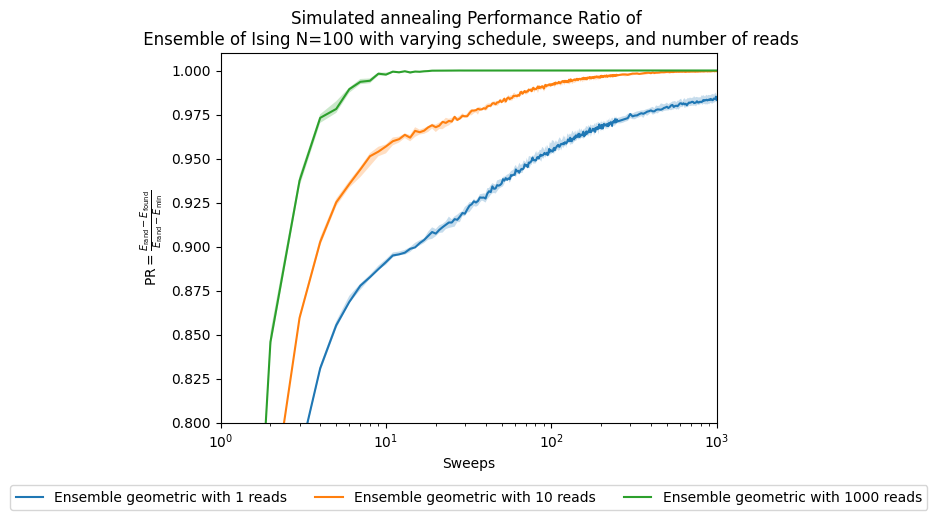

In [35]:
fig, ax = plt.subplots()
for boot in boots:
    for schedule in schedules:
        best_array = np.array([np.array(all_results[i]['best'][schedule][boot]) for i in range(20)])
        tsplotboot(
            ax,
            x=np.asarray(sweeps),
            data=best_array,
            error_est='bootstrap',
            seed_parts=(bootstrap_seed, SEED_TAG_ENSEMBLE_PR_SWEEPS, boot),
            label='Ensemble ' + schedule + ' with ' + str(boot) + ' reads',
        )
ax.set(xlabel='Sweeps')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of \n' +
          ' Ensemble of Ising N=100 with varying schedule, sweeps, and number of reads')
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.set(xscale='log')
ax.set(ylim=[0.8, 1.01])
plt.show()


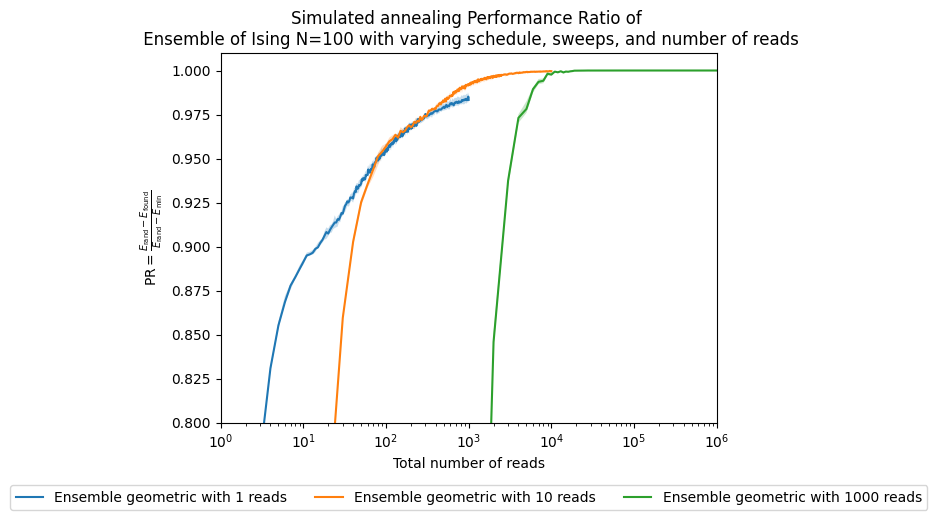

In [36]:
fig, ax = plt.subplots()
for boot in boots:
    reads = [s * boot for s in sweeps]
    for schedule in schedules:
        best_array = np.array([np.array(all_results[i]['best'][schedule][boot]) for i in range(20)])
        tsplotboot(
            ax,
            x=np.asarray(reads),
            data=best_array,
            error_est='bootstrap',
            seed_parts=(bootstrap_seed, SEED_TAG_ENSEMBLE_PR_READS, boot),
            label='Ensemble ' + schedule + ' with ' + str(boot) + ' reads',
        )
ax.set(xlabel='Total number of reads')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of \n' +
          ' Ensemble of Ising N=100 with varying schedule, sweeps, and number of reads')
plt.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.set(xscale='log')
ax.set(ylim=[0.8, 1.01])
plt.show()


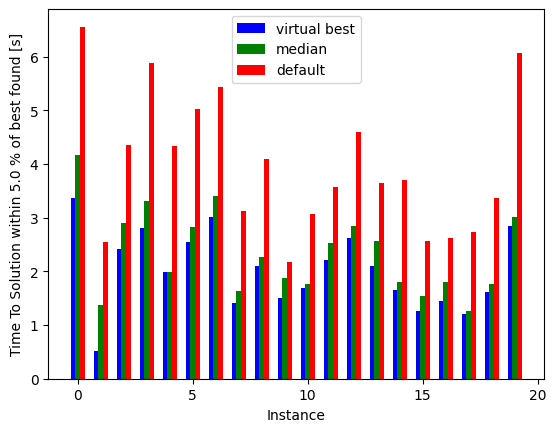

In [37]:
fig, ax = plt.subplots()
instances = np.arange(20)
indices = [np.argmin(all_results[i]['tts']['geometric'][default_sweeps]) for i in range(20)]
minima = [np.min(all_results[i]['tts']['geometric'][default_sweeps]) for i in range(20)]
default = [all_results[i]['tts']['geometric'][default_sweeps][-1] for i in range(20)]
median_all = [all_results[i]['tts']['geometric'][default_sweeps][min_median_index] for i in range(20)]

ax.bar(instances-0.2, minima, width=0.2, color='b', align='center', label='virtual best')
ax.bar(instances, median_all, width=0.2, color='g', align='center', label='median')
ax.bar(instances+0.2, default, width=0.2, color='r', align='center', label='default')
ax.xaxis.get_major_locator().set_params(integer=True)
plt.xlabel('Instance')
ax.set(ylabel='Time To Solution within ' + str(threshold) + ' % of best found [s]')
plt.legend()
plt.show()


Notice how much performance we lose by using the default sweep across all these instances, and how much we could gain if we somehow knew the best sweep for each instance.


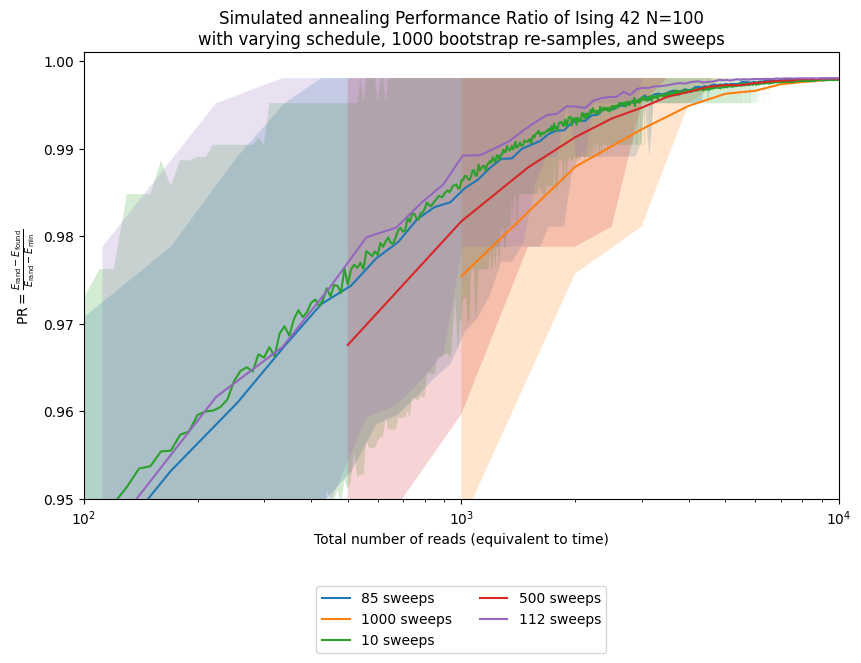

In [38]:
fig, ax = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
interest_sweeps = list(dict.fromkeys([min_sweep, default_sweeps, 10, 500, min_median_sweep]))
shots = list(range(1, total_reads))
n_boot_plot = 1000

instance = 42
for schedule in schedules:
    schedule_min_energy = results['min_energy'][schedule]
    schedule_random_energy = results['random_energy'][schedule]

    for sweep in interest_sweeps:
        if sweep not in approx_ratio[schedule]:
            samples, _ = load_or_generate_sa_samples(
                instance,
                schedule,
                sweep,
                model_random,
                simAnnSampler,
                pickle_path,
                overwrite_pickles=overwrite_pickles,
                total_reads=total_reads,
            )

            energies = np.asarray(samples.data_vectors['energy'], dtype=float)
            schedule_min_energy = min(schedule_min_energy, float(np.min(energies)))
            ratios, ratio_ci = build_performance_ratio_profile(
                energies,
                shots,
                n_boot=n_boot_plot,
                random_energy=schedule_random_energy,
                min_energy=schedule_min_energy,
                ci=ci,
                seed_parts=(bootstrap_seed, SEED_TAG_INSTANCE_42_TRANSFER_PROFILE, sweep),
            )
            approx_ratio[schedule][sweep] = ratios
            approx_ratioci[schedule][sweep] = ratio_ci

        reads = np.asarray([shot * sweep for shot in shots], dtype=float)
        ax.plot(reads, approx_ratio[schedule][sweep], label=str(sweep) + ' sweeps')
        ratio_ci = np.asarray(approx_ratioci[schedule][sweep], dtype=float)
        ax.fill_between(reads, ratio_ci[:, 0], ratio_ci[:, 1], alpha=0.2)

ax.set(xscale='log')
ax.set(ylim=[0.95, 1.001])
ax.set(xlim=[1e2, 1e4])
ax.set(xlabel='Total number of reads (equivalent to time)')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of Ising 42 N=100\n' +
          'with varying schedule, ' + str(n_boot_plot) + ' bootstrap re-samples, and sweeps')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)
plt.show()


This example shows that for instance 42, using the sweep selected from the ensemble median is better than using the default, although it still does not match the unattainable virtual best for that instance.


After figuring out what would be the best parameter for our instance of interest, it is also useful to look at the ensemble performance.
We can compare the default sweep, the sweep selected from the ensemble statistic, and the unattainable virtual best where each instance gets its own optimal sweep.
This helps us understand how much is at stake in the parameter choice.


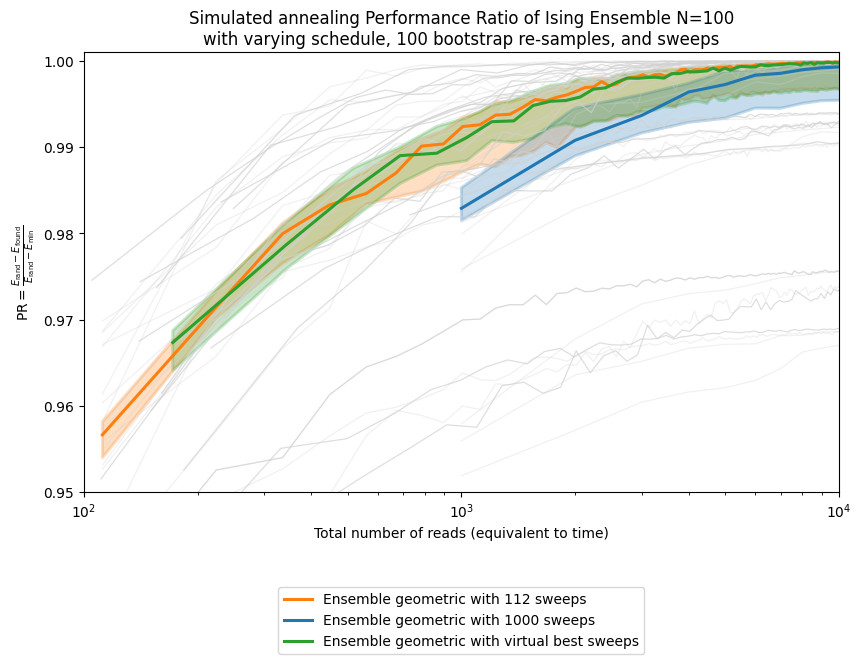

In [39]:
fig, ax = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
default_sweeps = 1000
interest_sweeps = [min_median_sweep, default_sweeps, 'best']
n_boot_plot = 100
shots = list(range(1, total_reads))
overwrite_pickles = False

all_approx_ratio = {}
profile_colors = {
    str(default_sweeps): '#1f77b4',
    str(min_median_sweep): '#ff7f0e',
    'best': '#2ca02c',
}

for instance in instances:
    all_approx_ratio[instance] = {}
    for schedule in schedules:
        all_approx_ratio[instance][schedule] = {}

    _, _, instance_model = build_random_ising_instance(instance, N)

    for sweep in interest_sweeps:
        flag_best = False
        current_sweep = sweep
        if sweep == 'best':
            current_sweep = sweeps[indices[instance]]
            flag_best = True

        for schedule in schedules:
            if current_sweep in all_approx_ratio[instance][schedule]:
                ratios = all_approx_ratio[instance][schedule][current_sweep]
            else:
                min_energy = all_results[instance]['min_energy'][schedule][default_sweeps]
                random_energy = all_results[instance]['random_energy'][schedule][default_sweeps]
                samples, _ = load_or_generate_sa_samples(
                    instance,
                    schedule,
                    current_sweep,
                    instance_model,
                    simAnnSampler,
                    pickle_path,
                    overwrite_pickles=overwrite_pickles,
                    total_reads=total_reads,
                )

                energies = np.asarray(samples.data_vectors['energy'], dtype=float)
                min_energy = min(min_energy, float(np.min(energies)))
                ratios, _ = build_performance_ratio_profile(
                    energies,
                    shots,
                    n_boot=n_boot_plot,
                    random_energy=random_energy,
                    min_energy=min_energy,
                    ci=ci,
                    seed_parts=(bootstrap_seed, SEED_TAG_ENSEMBLE_TRANSFER_PROFILE, instance, current_sweep),
                )
                all_approx_ratio[instance][schedule][current_sweep] = ratios

            plot_key = 'best' if flag_best else str(current_sweep)
            all_approx_ratio[instance][schedule][plot_key] = ratios
            ax.plot(
                [shot * current_sweep for shot in shots],
                ratios,
                color='0.82',
                label=None,
                alpha=0.7 if flag_best else 0.3,
                linewidth=0.9,
            )

virtual_best_sweep = int(np.round(np.median([sweeps[idx] for idx in indices])))

for schedule in schedules:
    summary_specs = [
        (str(min_median_sweep), min_median_sweep, 'Ensemble ' + schedule + ' with ' + str(min_median_sweep) + ' sweeps'),
        (str(default_sweeps), default_sweeps, 'Ensemble ' + schedule + ' with ' + str(default_sweeps) + ' sweeps'),
        ('best', virtual_best_sweep, 'Ensemble ' + schedule + ' with virtual best sweeps'),
    ]

    for sweep_key, plot_sweep, label_plot in summary_specs:
        approx_ratio_array = np.asarray([
            np.asarray(all_approx_ratio[i][schedule][sweep_key], dtype=float)
            for i in instances
        ], dtype=float)
        reads = np.asarray([shot * plot_sweep for shot in shots], dtype=float)
        tsplotboot(
            ax,
            x=reads,
            data=approx_ratio_array,
            error_est='bootstrap',
            seed_parts=(bootstrap_seed, SEED_TAG_ENSEMBLE_TRANSFER_PROFILE, int(plot_sweep)),
            label=label_plot,
            color=profile_colors[sweep_key],
            linewidth=2.2,
        )

ax.set(xscale='log')
ax.set(ylim=[0.95, 1.001])
ax.set(xlim=[1e2, 1e4])
ax.set(xlabel='Total number of reads (equivalent to time)')
ax.set_ylabel(performance_ratio_label)
ax.set_title('Simulated annealing Performance Ratio of Ising Ensemble N=100\n' +
             'with varying schedule, ' + str(n_boot_plot) + ' bootstrap re-samples, and sweeps')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1)
plt.show()


As you can see, there is a gap between the ensemble-selected sweep and the virtual best.
That gap is small in this example, but it can become much larger as the parameter space grows, making parameter selection both more valuable and more difficult.
We are actively working on such parameter-setting strategies and expect to report further progress in this area.
